In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
# lägg till data
# Guld data från yfinance
gold_data = yf.download("GC=F", start="2025-05-01", end="2026-04-30")
gold_close = gold_data[['Close']]
# API Data
file_path = '../data/interim/master_cleaned.csv'
df = pd.read_csv(file_path, parse_dates=['date'])

# Normalisera data
gold_start = gold_data['Close'].iloc[0]
gold_norm = (gold_data['Close'] / gold_start) * 100

crypto_norm_list = []
for coin in df['coin_id'].unique():
    subset = df[df['coin_id'] == coin].sort_values('date').copy()
    start_val = subset['price'].iloc[0]
    subset['price_norm'] = (subset['price'] / start_val) * 100
    crypto_norm_list.append(subset)

df_norm = pd.concat(crypto_norm_list)

[*********************100%***********************]  1 of 1 completed


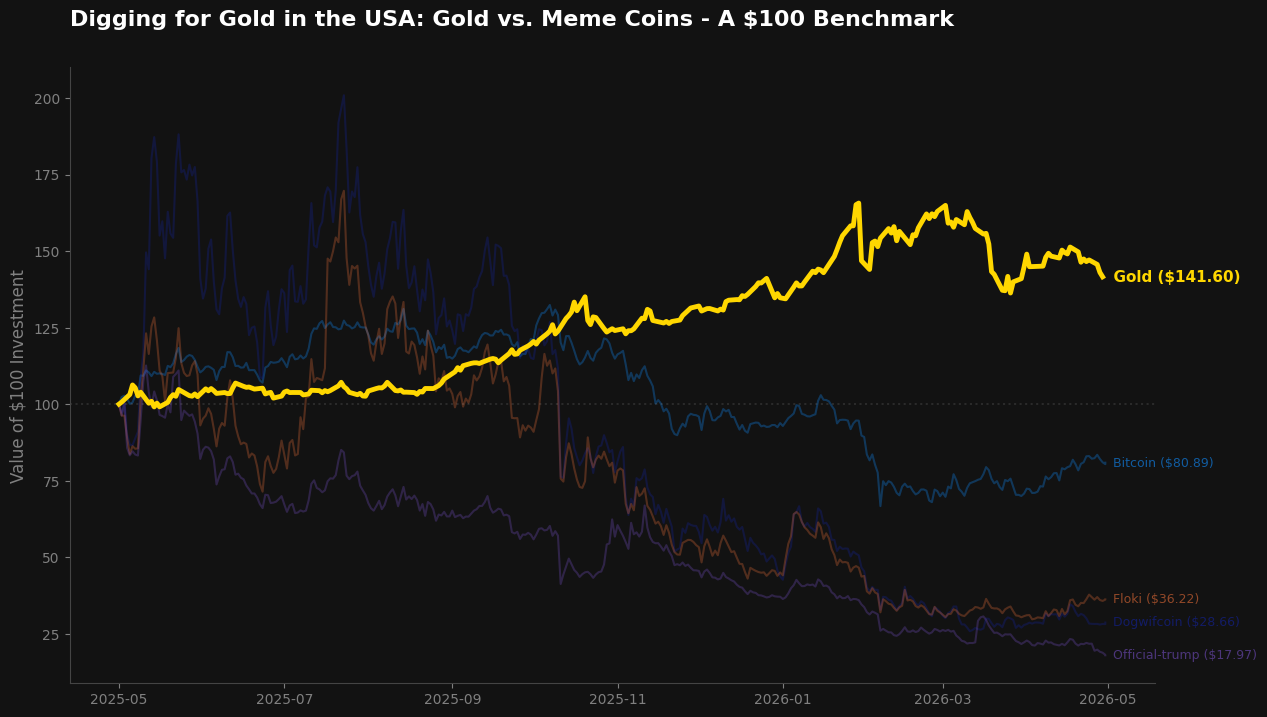

In [6]:
bg_color = '#121212'
plt.rcParams['axes.facecolor'] = bg_color
plt.rcParams['figure.facecolor'] = bg_color

fig, ax = plt.subplots(figsize=(14, 8))

colors = {
    'bitcoin': '#118DFF', 'dogwifcoin': '#12239E', 'floki': '#E66C37', 'official-trump': '#744EC2'
}

# Plotta guld
ax.plot(gold_data.index, gold_norm, color='#FFD700', linewidth=3.5, zorder=10)
gold_last_val = gold_norm.values.flatten()[-1]
ax.text(gold_data.index[-1], gold_last_val, f'  Gold (${gold_last_val:.2f})',
        color='#FFD700', va='center', fontweight='bold', fontsize=11)

# Plotta krypto
for coin, color in colors.items():
    data = df_norm[df_norm['coin_id'] == coin].sort_values('date')
    if not data.empty:
        ax.plot(data['date'], data['price_norm'], color=color, alpha=0.3, linewidth=1.5)
        coin_last_val = data['price_norm'].values.flatten()[-1]
        ax.text(data['date'].iloc[-1], coin_last_val, f"  {coin.capitalize()} (${coin_last_val:.2f})",
                color=color, va='center', alpha=0.6, fontsize=9)

# Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444444')
ax.spines['bottom'].set_color('#444444')

ax.grid(False)
ax.axhline(100, color='white', linestyle=':', alpha=0.1)
ax.tick_params(colors='gray', labelsize=10)

ax.set_title('Digging for Gold in the USA: Gold vs. Meme Coins - A $100 Benchmark',
             color='white', loc='left', pad=30, fontsize=16, fontweight='bold')
ax.set_ylabel('Value of $100 Investment', color='gray', fontsize=12)

# Spara och visa
plt.savefig('../viktor_storytelling/gold_analysis_Viktor.png', dpi=300, bbox_inches='tight', facecolor=bg_color)
plt.show()


In [5]:
# Beräkna årlig volatilitet för riskjämförelse
# 252 dagar handel för guld pga stängt på helger
gold_vol = gold_data['Close'].pct_change().std() * np.sqrt(252) 

print(f"{'Asset':<15} | {'Annualized Volatility':<25} | {'Final Value ($100)':<15}")
print("-" * 65)

g_vol_val = gold_vol.values.flatten()[0]
g_final_val = gold_norm.values.flatten()[-1]

print(f"{'Gold':<15} | {g_vol_val:24.2%} | ${g_final_val:14.2f}")

for coin in colors:
    c_data = df[df['coin_id'] == coin].sort_values('date')
    # 365 dagar handel för crypto
    c_vol = (c_data['daily_return_pct']/100).std() * np.sqrt(365)
    c_final = (c_data['price'].iloc[-1] / c_data['price'].iloc[0]) * 100
    print(f"{coin.capitalize():<15} | {c_vol:24.2%} | ${c_final:14.2f}")

Asset           | Annualized Volatility     | Final Value ($100)
-----------------------------------------------------------------
Gold            |                   27.28% | $        141.60
Bitcoin         |                   42.64% | $         80.89
Dogwifcoin      |                  123.30% | $         28.66
Floki           |                  107.45% | $         36.22
Official-trump  |                   85.88% | $         17.97
